# Bitcoin Persistence-Enhanced Log-Return Transformer

## Role
Final supervised Transformer evidence.

## Inputs
Frozen validated, PE-Transformer, PE-LSTM, and ARIMA vectors.

## Outputs
Artifact-derived final comparison.

## Depends On
01 and 03.

## Authoritative Status
AUTHORITATIVE MODEL ANALYSIS

## What This Notebook Does Not Do
Safe Run All does not train TensorFlow; raw-price Transformer variants are not ranked.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.bitcoin_pipeline import *
RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False


## Final design
The model uses 128 prior log returns, train-only scaling, deterministic seed controls, and persistence-anchored price reconstruction.

In [2]:
# Load the canonical split and frozen forecasts.
_, target = load_bitcoin_target(ROOT)
train, test = canonical_split(target)
validated = load_validated_forecasts(ROOT)
forecasts = forecast_series(validated, target)

# Select and compare the four models used in this notebook.
names = [
    'Naive',
    'ARIMA Rolling One-Step',
    'Persistence-Enhanced Log-Return LSTM',
    'Persistence-Enhanced Log-Return Transformer',
]
transformer_comparison = metric_table(
    validated.Actual,
    {name: forecasts[name] for name in names},
    train,
).sort_values('RMSE')
transformer_comparison

,MAE,RMSE,MAPE,sMAPE,MASE,N,Relative MAE vs Naive
Model,,,,,,,
Naive,1290.353242,1853.624774,1.742747,1.744142,4.575633,1061,1.000000
ARIMA Rolling One-Step,1299.874638,1866.302859,1.754004,1.754209,4.609396,1061,1.007379
Persistence-Enhanced Log-Return LSTM,1321.365311,1881.091190,1.783956,1.791645,4.685603,1061,1.024034
Persistence-Enhanced Log-Return Transformer,2019.366342,2559.749810,2.710936,2.759271,7.160736,1061,1.564972


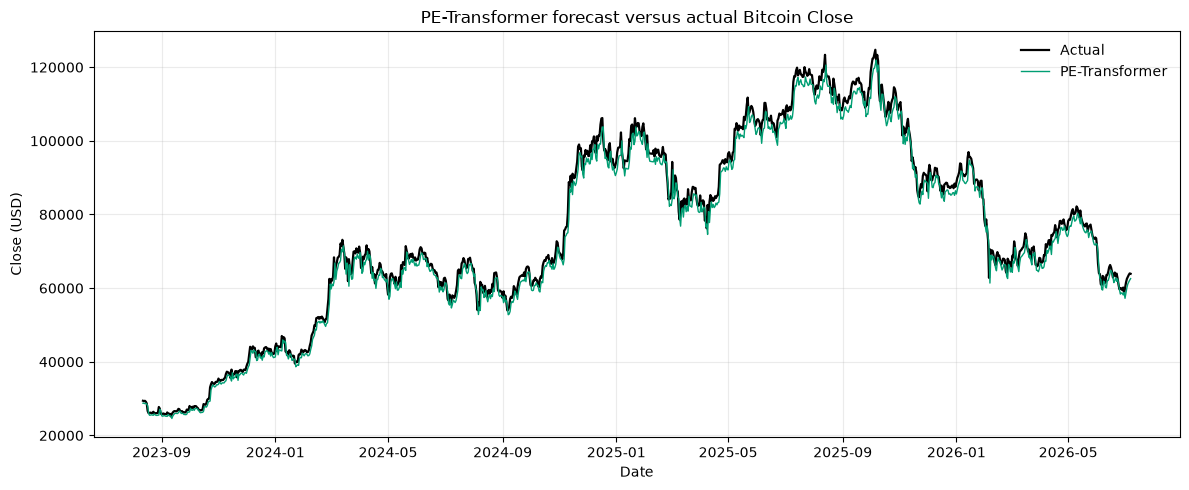

In [3]:
import matplotlib.pyplot as plt

# Compare the frozen PE-Transformer forecast with held-out actual prices.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(validated.index, validated.Actual, color='black', linewidth=1.6, label='Actual')
ax.plot(validated.index, validated.Persistence_Enhanced_Transformer, color='#009E73', linewidth=1.0, label='PE-Transformer')
ax.set(title='PE-Transformer forecast versus actual Bitcoin Close', xlabel='Date', ylabel='Close (USD)')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

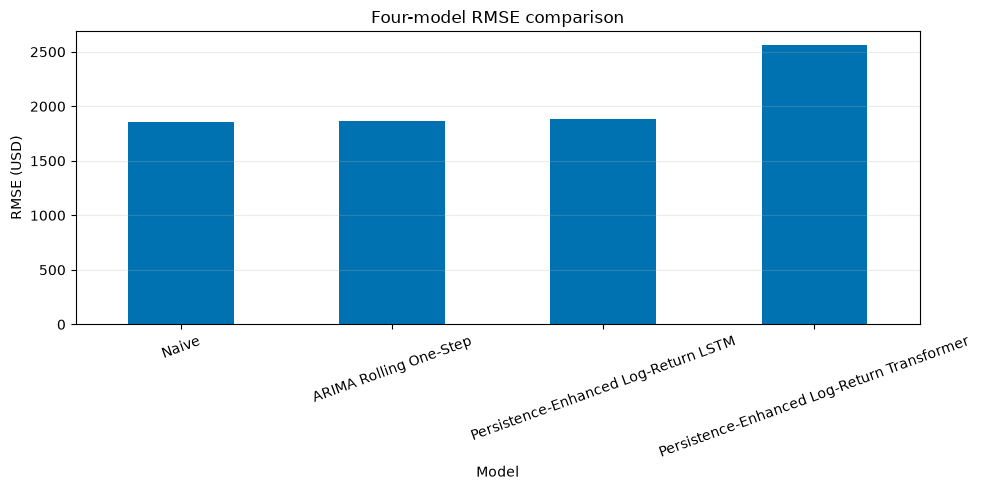

In [4]:
# Plot the same four-model RMSE values shown in the table.
ax = transformer_comparison['RMSE'].sort_values().plot(kind='bar', figsize=(10, 5), color='#0072B2')
ax.set(title='Four-model RMSE comparison', xlabel='Model', ylabel='RMSE (USD)')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.25)
ax.figure.tight_layout()
plt.show()

## Development appendix
Transformer v1, corrected raw-price Transformer, and positional raw-price Transformer are historical diagnostics only.

## Key Findings

Among the four displayed systems, the table and bar chart show the frozen RMSE ordering under the same rolling one-step test protocol. The PE-Transformer trajectory remains close to the observed price path, but the persistence and ARIMA comparators retain lower RMSE in this comparison; historical Transformer variants remain diagnostic-only.